# Interpolate initial temperature and thickness

In the 0.25 degree ANU-TUB model I generated some HYCOM initial conditions for salinity, temperature and thickness, then passed these to each coordinate to remap and run.
In this notebook I am going to interpolate these initial conditions on to the 1 degree grid.
I am using Interpolations.jl and just using bilinear interpolation.

In [1]:
one_degree_input = "/g/data/e14/jb2381/one-degree-anu-tub/input/anu-tub"
if pwd() != one_degree_input
    cd(one_degree_input)
end

using Pkg
Pkg.activate(".")

using NCDatasets, CairoMakie, Interpolations

  Activating project at `/g/data/e14/jb2381/one-degree-anu-tub/input/anu-tub`


## HYCOM 0.25 degree initial conditions

I will be able to copy across the `zl`, `Layer` and `Interface` dimensions.
`SALT` is constant at 35, so I can create this array.
This means I need to interpolate the temperature and thickness.
Then from the thickness need the `eta` variable.

The interpolation is only horizontal, so I will loop through the layers.

In [41]:
hycom_ics = joinpath(@__DIR__, "../../../anu-tub/input/anu-tub/hycom_initial_conditions.nc")

"/g/data/e14/jb2381/one-degree-anu-tub/input/anu-tub/../../../anu-tub/input/anu-tub/hycom_initial_conditions.nc"

In [42]:
ds = NCDataset(hycom_ics, maskingvalue = NaN)
xh = ds["xh"][:]
yh = ds["yh"][:]
zl = -ds["zl"][:]
θ = ds["PTEMP"][:, :, :]
h = ds["h"][:, :, :]
eta = ds["eta"][:, :, :]
layers = ds.dim["Layer"]
close(ds)

closed Dataset

## Interpolation from 0.25 to 1 degree grid

In [43]:
ds = NCDataset("one_degree_topog.nc")
nx = ds.dim["x"]
ny = ds.dim["y"]
x1deg = ds["x"][:]
y1deg = ds["y"][:]
depth = ds["topog"][:, :, end]
close(ds)

# Make a mesh of grids.
X = x1deg .* ones(ny)'
Y = ones(nx) .* y1deg'
nothing

In [44]:
nodes = (xh, yh)
interp = interpolate(nodes, θ[:, :, 1], Gridded(Linear()))

sst_interp = interp.(X, Y)
nothing

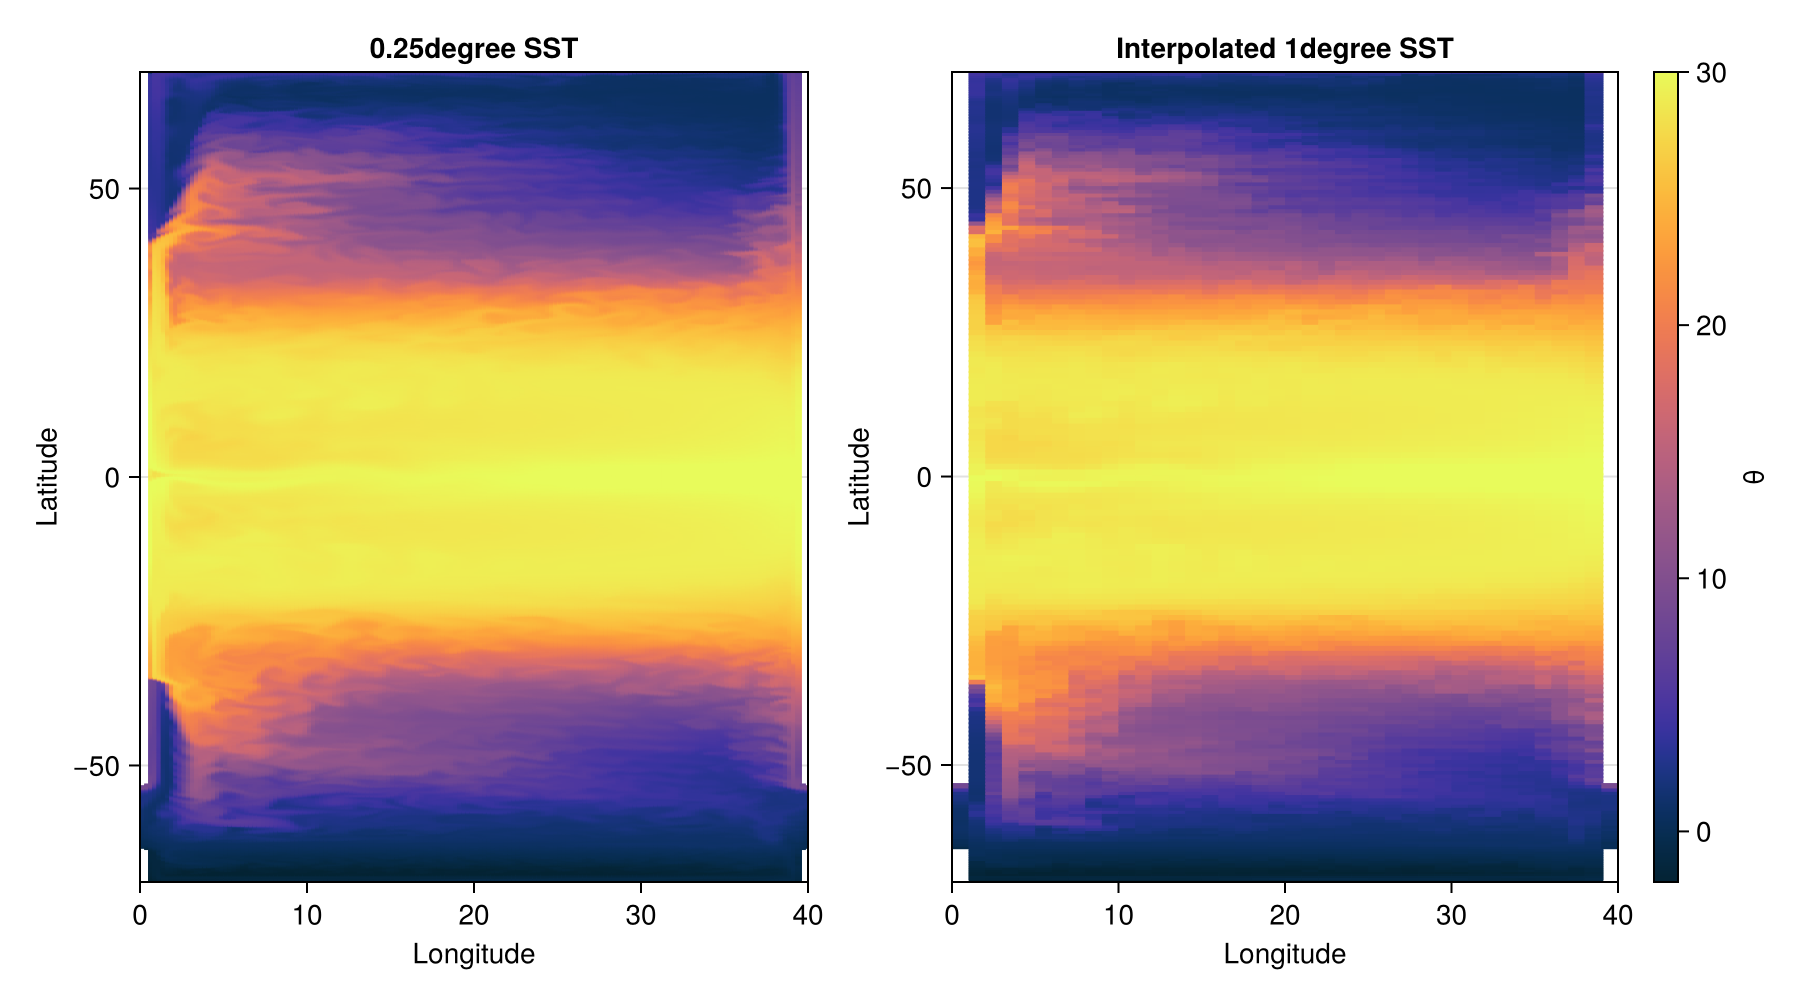

In [45]:
colormap = :thermal
colorrange = (-2, 30)

fig = Figure(size = (900, 500))
ax = Axis(fig[1, 1], xlabel = "Longitude", ylabel = "Latitude", title = "0.25degree SST")
hm = heatmap!(ax, xh, yh, θ[:, :, 1]; colormap, colorrange)

ax = Axis(fig[1, 2], xlabel = "Longitude", ylabel = "Latitude", title = "Interpolated 1degree SST")
heatmap!(ax, x1deg, y1deg, sst_interp; colormap, colorrange)

Colorbar(fig[1, 3], hm, label = "θ")
fig

Now loop over all layers for both thickness and temperature.

In [46]:
θ_interp = Array{Float64}(undef, nx, ny, layers)
h_interp = Array{Float64}(undef, nx, ny, layers)
S_interp = Array{Float64}(undef, nx, ny, layers)
eta_interp = Array{Float64}(undef, nx, ny, layers + 1)
nodes = (xh, yh)

for k ∈ 1:layers
    # temperature
    interp_θ = interpolate(nodes, θ[:, :, k], Gridded(Linear()))
    θ_interp[:, :, k] .= interp_θ.(X, Y)
    # thickness
    interp_h = interpolate(nodes, h[:, :, k], Gridded(Linear()))
    h_interp[:, :, k] = interp_h.(X, Y)
end

for k ∈ 1:layers+1
    # eta
    interp_e = interpolate(nodes, eta[:, :, k], Gridded(Linear()))
    eta_interp[:, :, k] = interp_e.(X, Y)
end

# set constant salinity with `NaN` where θ is.
S_interp .= 35

find_nan = .!isnan.(θ_interp) .== true
S_interp .*= find_nan

# calculate eta from h
# eta_interp[:, :, layers + 1] = -depth
# for k ∈ layers:-1:1
#     eta_interp[:, :, k] .= eta_interp[:, :, k + 1] + h_interp[:, :, k]
# end
# eta_interp[:, :, 1] .= 0
# for k ∈ 1:layers
#     eta_interp[:, :, k+1] .= eta_interp[:, :, k] + h_interp[:, :, k]
# end

@info "Temperature and thickness interpolated, salinity set constant, eta calculated"

[ Info: Temperature and thickness interpolated, salinity set constant, eta calculated


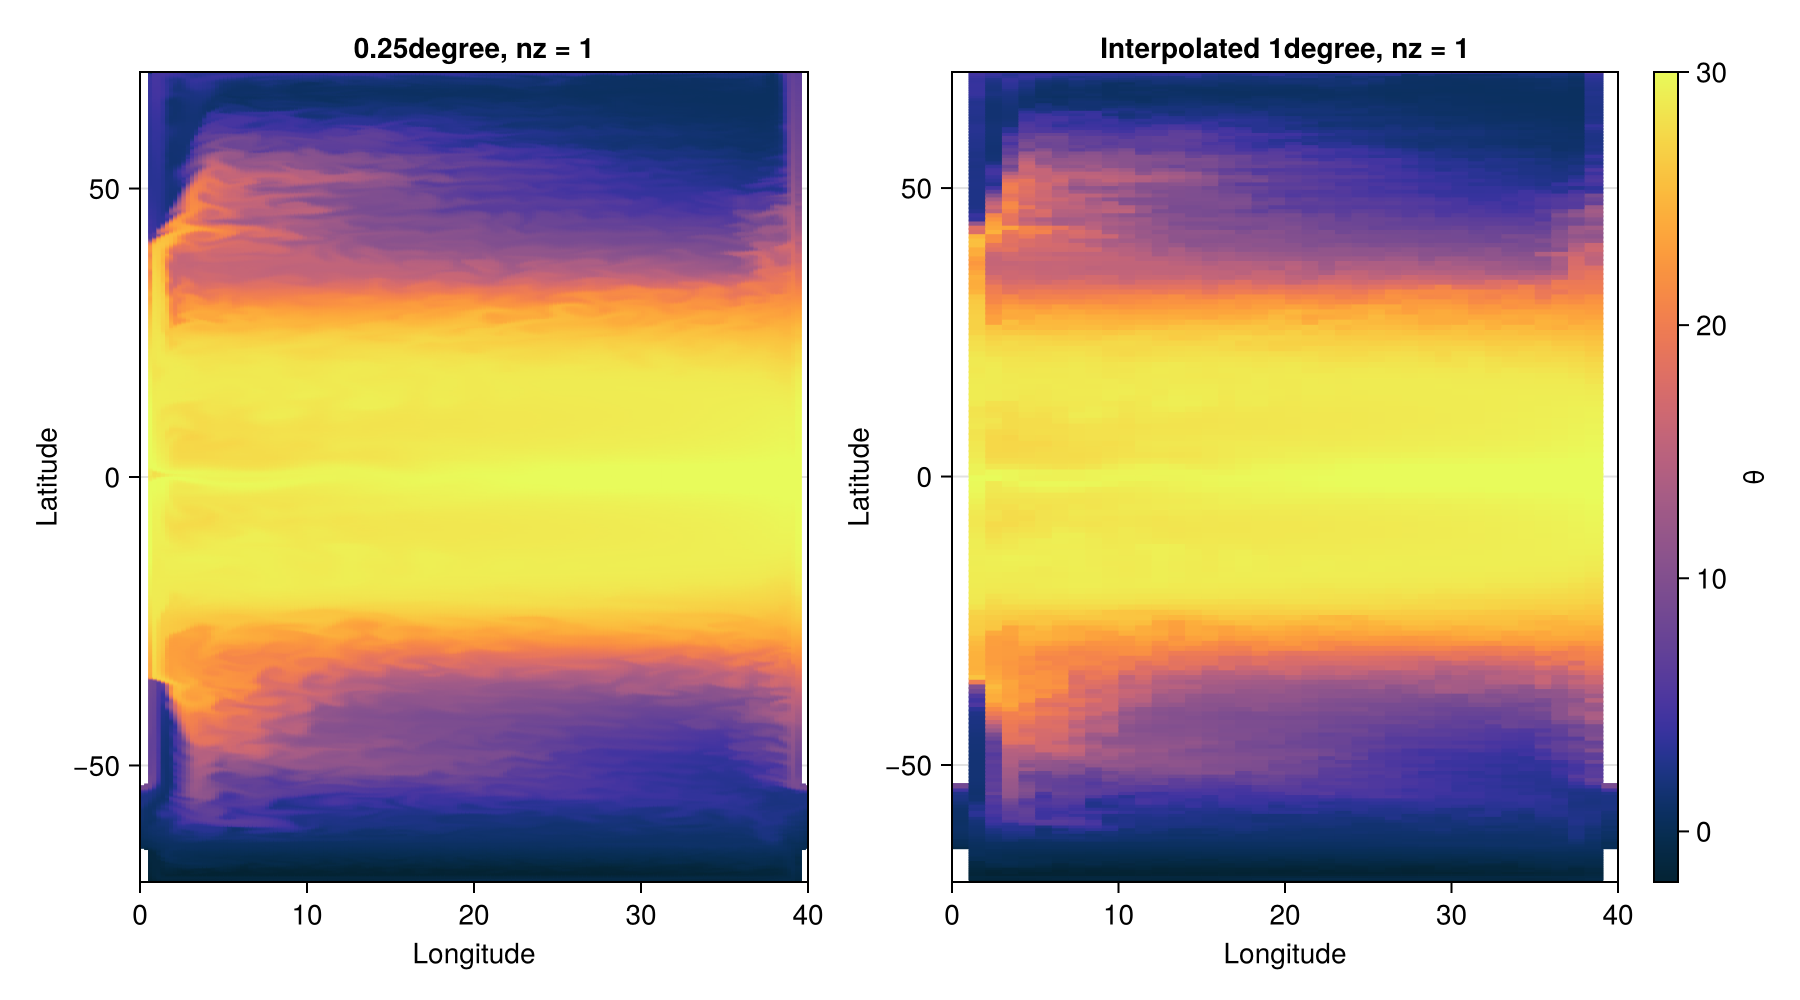

In [47]:
layer = 1

colormap = :thermal
colorrange = (-2, 30)

fig = Figure(size = (900, 500))
ax = Axis(fig[1, 1], xlabel = "Longitude", ylabel = "Latitude", title = "0.25degree, nz = $layer")
hm = heatmap!(ax, xh, yh, θ[:, :, layer]; colormap, colorrange)

ax = Axis(fig[1, 2], xlabel = "Longitude", ylabel = "Latitude", title = "Interpolated 1degree, nz = $layer")
heatmap!(ax, x1deg, y1deg, θ_interp[:, :, layer]; colormap, colorrange)

Colorbar(fig[1, 3], hm, label = "θ")
fig

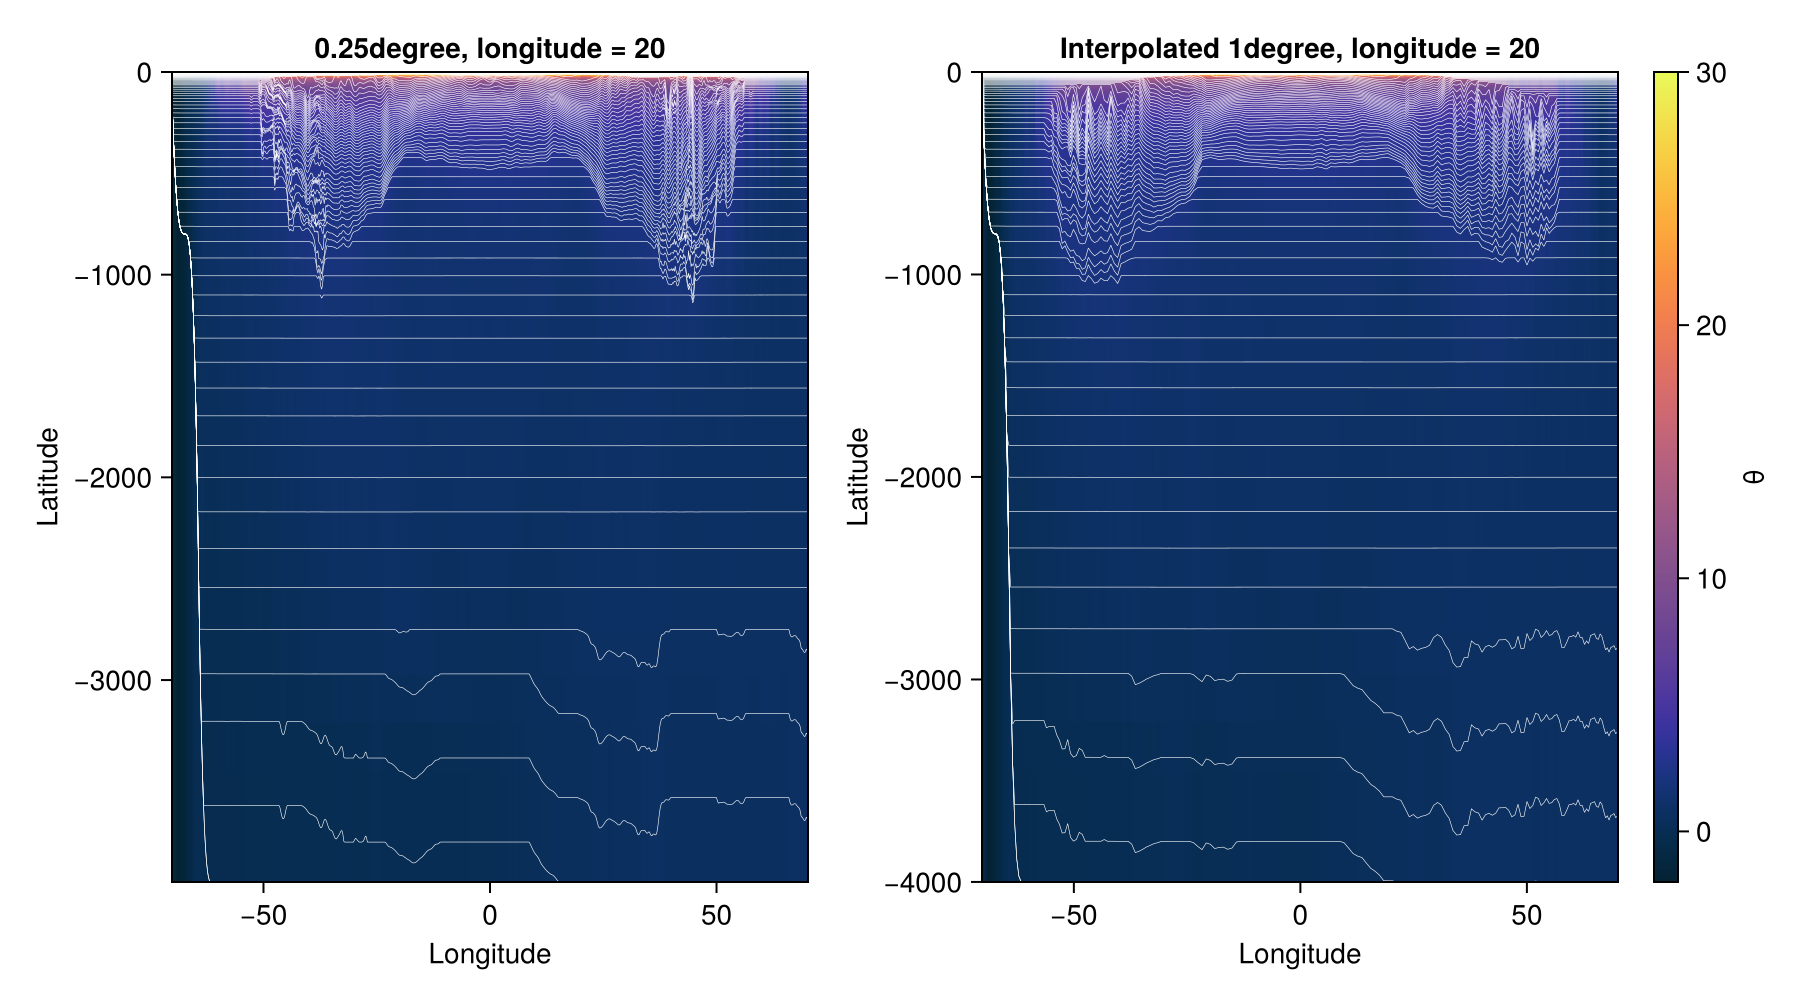

In [48]:
long_slice = 20
∫h = cumsum(h, dims = 3)
∫h_interp = cumsum(h_interp, dims = 3)

colormap = :thermal
colorrange = (-2, 30)

fig = Figure(size = (900, 500))
ax = Axis(fig[1, 1], xlabel = "Longitude", ylabel = "Latitude", title = "0.25degree, longitude = $long_slice")
hm = heatmap!(ax, yh, zl, θ[long_slice, :, :]; colormap, colorrange)
for k ∈ 1:layers
    lines!(ax, yh, -∫h[long_slice, :, k], color = :white, linewidth = 0.3)
end

ax2 = Axis(fig[1, 2], xlabel = "Longitude", ylabel = "Latitude", title = "Interpolated 1degree, longitude = $long_slice")
heatmap!(ax2, y1deg, zl, θ_interp[long_slice, :, :]; colormap, colorrange)
for k ∈ 1:layers
    lines!(ax2, y1deg, -∫h_interp[long_slice, :, k], color = :white, linewidth = 0.3)
end

Colorbar(fig[1, 3], hm, label = "θ")
fig

Don't think the bilinear interpolation here is good for thickness but we see.

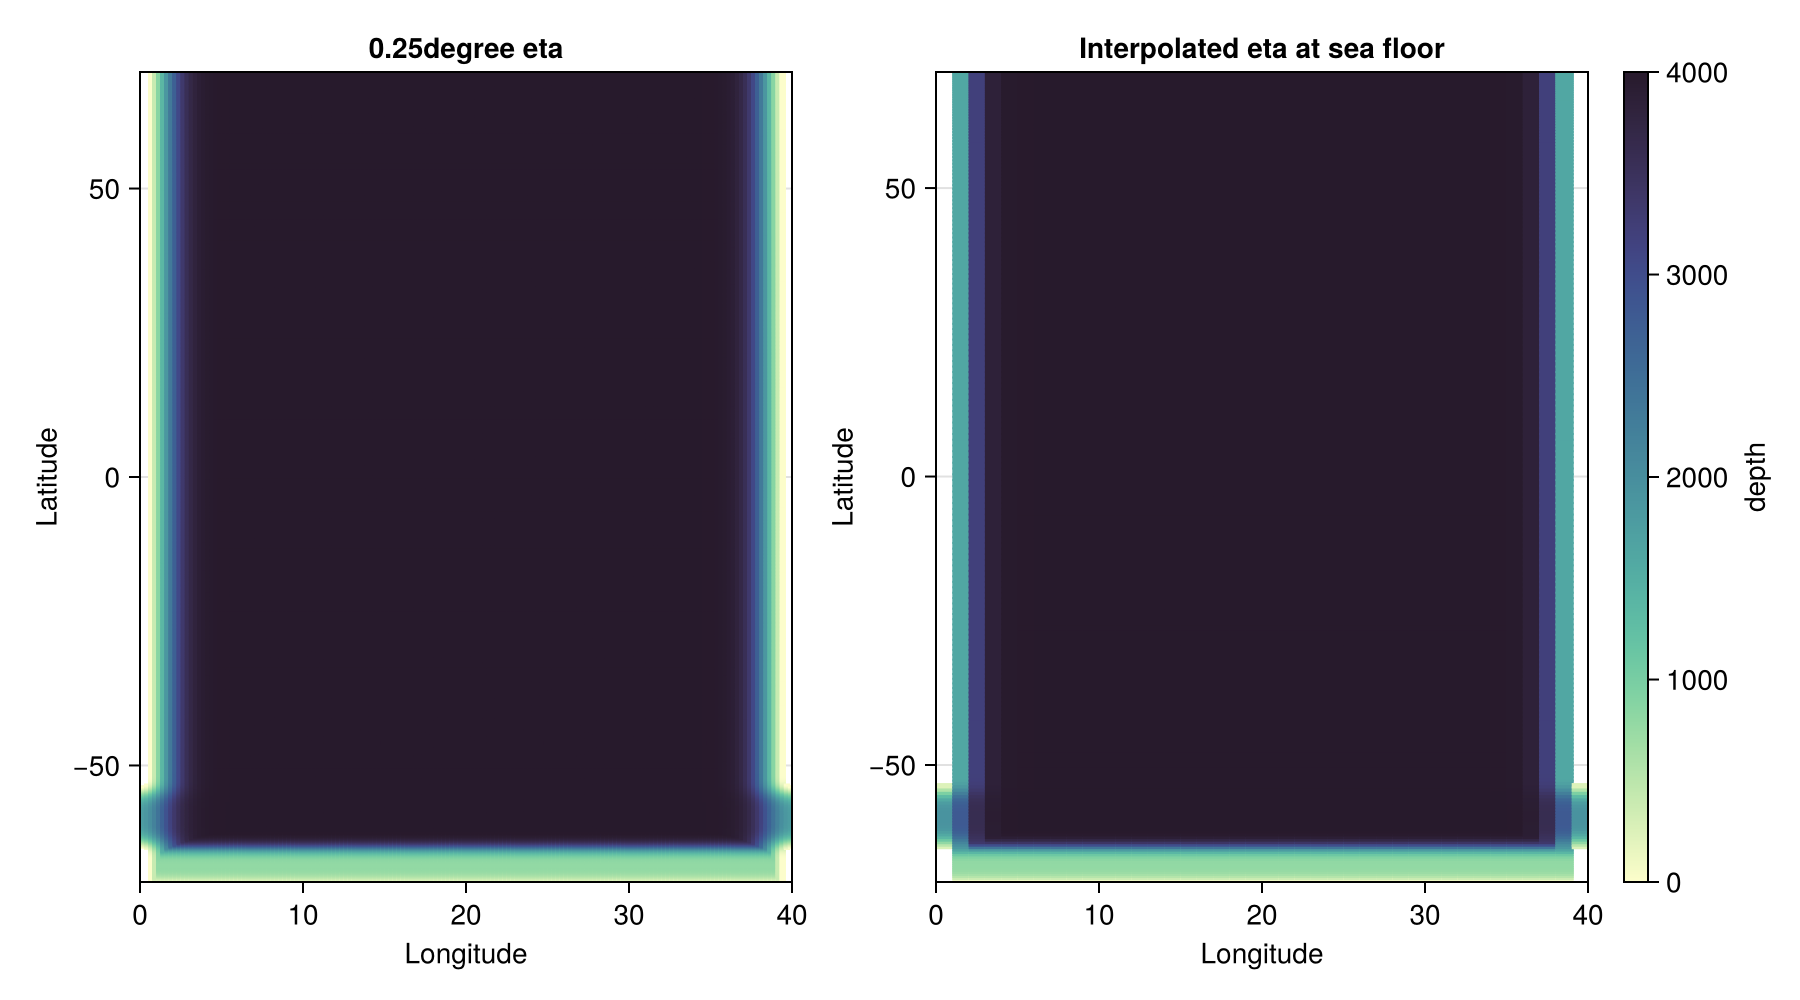

In [49]:
layer = 1

colormap = :deep
colorrange = (0, 4000)

fig = Figure(size = (900, 500))
ax = Axis(fig[1, 1], xlabel = "Longitude", ylabel = "Latitude", title = "0.25degree eta")
hm = heatmap!(ax, xh, yh, abs.(eta[:, :, end]); colormap, colorrange)

ax = Axis(fig[1, 2], xlabel = "Longitude", ylabel = "Latitude", title = "Interpolated eta at sea floor")
heatmap!(ax, x1deg, y1deg, abs.(eta_interp[:, :, end]); colormap, colorrange)

Colorbar(fig[1, 3], hm, label = "depth")
fig

## Save one degree initial conditions

In [50]:
replace!(S_interp, 0 => 1.0e20)
replace!(θ_interp, NaN => 1.0e20)
replace!(h_interp, NaN => 1.0e20)
replace!(eta_interp, NaN => 1.0e20)

ds = NCDataset(hycom_ics, maskingvalue = NaN)

ic_filename = "one_degree_hycom_ics.nc"
NCDataset(ic_filename, "c") do _ds
    
    defDim(_ds, "lonh", nx)
    defDim(_ds, "lath", ny)
    defDim(_ds, "Layer", layers)
    defDim(_ds, "Interface", layers+1)
    
    defVar(_ds, "h", h_interp, ("lonh", "lath", "Layer"), fillvalue = 1.0e20,
            attrib = Dict("long_name" => "h point layer thickness", "units" => "m", "missing_value" => 1.0e20))
    defVar(_ds, "eta", eta_interp, ("lonh", "lath", "Interface"), fillvalue = 1.0e20, 
            attrib = Dict("long_name" => "Interface Height Relative to Mean Sea Level", "units" => "m", "missing_value" => 1.0e20))
    defVar(_ds, "PTEMP", θ_interp, ("lonh", "lath", "Layer"), fillvalue = 1.0e20,
            attrib = Dict("long_name" => "Potential temperature", "units" => "degC", "missing_value" => 1.0e20))
    defVar(_ds, "SALT", S_interp, ("lonh", "lath", "Layer"), fillvalue = 1.0e20,
            attrib = Dict("long_name" => "Salinity", "units" => "PPT", "missing_value" => 1.0e20))
    
    defVar(_ds, "xh", x1deg, ("lonh",))
    defVar(_ds, "yh", y1deg, ("lath",))
    defVar(_ds, ds["zl"])

end
@info "Initial conditions saved to $(ic_filename)"

close(ds)

[ Info: Initial conditions saved to one_degree_hycom_ics.nc


closed Dataset

In [51]:
ds = NCDataset("one_degree_hycom_ics.nc", maskingvalue = NaN)

Dataset: one_degree_hycom_ics.nc
Group: /

Dimensions
   lonh = 40
   lath = 200
   Layer = 75
   Interface = 76
   zl = 75

Variables
  h   (40 × 200 × 75)
    Datatype:    Float64 (Float64)
    Dimensions:  lonh × lath × Layer
    Attributes:
     _FillValue           = 1.0e20
     units                = m
     missing_value        = 1.0e20
     long_name            = h point layer thickness

  eta   (40 × 200 × 76)
    Datatype:    Float64 (Float64)
    Dimensions:  lonh × lath × Interface
    Attributes:
     _FillValue           = 1.0e20
     units                = m
     missing_value        = 1.0e20
     long_name            = Interface Height Relative to Mean Sea Level

  PTEMP   (40 × 200 × 75)
    Datatype:    Float64 (Float64)
    Dimensions:  lonh × lath × Layer
    Attributes:
     _FillValue           = 1.0e20
     units                = degC
     missing_value        = 1.0e20
     long_name            = Potential temperature

  SALT   (40 × 200 × 75)
    Datatype:    Flo

In [52]:
close(ds)

closed Dataset